### Ejericicio Clustering 1

Suponer que representamos cada cluster de puntos de dos coordenadas numéricas mediante listas (o arrays).
Definir una función que, dado un cluster y dado un punto adicional (con 2 coordenadas), determine cuál punto del cluster ese el más cercano.


- Sabemos que un cluster es un grupo de puntos o puntos en un eje de coordenadas
- Crear una función que reciba un punto (2, 7) y en base a un cluster de puntos, determinar que punto es el más cercano

#### Input

$$
[
    (1.2, 2.3),
    (4.5, 5.8),
    (1.1, 2.1),
    (9.0, 8.5),
    (2.0, 3.1),
    (4.8, 6.0),
    (0.5, 0.8),
    (8.7, 9.2),
    (5.1, 5.5),
    (1.5, 1.9)
]
$$

$$(4.0, 5.0)$$

#### Output

$$(4.5, 5.8)$$


In [60]:
import math


def dis_euclidiana(punto_a, punto_b):

    if punto_a is None or punto_b is None:
        print("La función debe recibir un punto A y B")
        return

    a_x = punto_a[0]
    a_y = punto_a[1]

    b_x = punto_b[0]
    b_y = punto_b[1]

    distancia = math.sqrt(((a_x - b_x) ** 2) + ((a_y - b_y) ** 2))

    return distancia

In [61]:
def obtener_punto_cercano_en_cluster(cluster, ref_punto):

    if cluster is None or ref_punto is None:
        print("La función debe recibir un cluster y un punto de referencia")
        return

    punto_min = cluster[0]
    for punto in cluster:
        if dis_euclidiana(punto, ref_punto) < dis_euclidiana(punto_min, ref_punto):
            punto_min = punto

    return punto_min


cluster = [
    (1.2, 2.3),
    (4.5, 5.8),
    (1.1, 2.1),
    (9.0, 8.5),
    (2.0, 3.1),
    (4.8, 6.0),
    (0.5, 0.8),
    (8.7, 9.2),
    (5.1, 5.5),
    (1.5, 1.9),
]

ref_punto = (8.8, 9)

punto_mas_cercano = obtener_punto_cercano_en_cluster(cluster, ref_punto)

punto_mas_cercano

(8.7, 9.2)

#### Calcular Centroide Cluster


In [62]:
cluster = [(1.2, 2.3), (4.5, 6.7), (7.8, 9.1)]

prom_x = sum(punto[0] for punto in cluster) / len(cluster)
prom_y = sum(punto[1] for punto in cluster) / len(cluster)

centroide = (prom_x, prom_y)

centroide

(4.5, 6.033333333333334)

# Ejericicio Clustering 2

Calcular dado un cluster, su radio y su diametro

Input

$$
[
    (1.2, 2.3),
    (4.5, 5.8),
    (1.1, 2.1),
    (9.0, 8.5),
    (2.0, 3.1),
    (4.8, 6.0),
    (0.5, 0.8),
    (8.7, 9.2),
    (5.1, 5.5),
    (1.5, 1.9)
]
$$

Output
$$Radio: 5.0$$
$$Diametro: 10.0$$


In [63]:
cluster = [
    (0.2, 9.8),
    (15.3, -4.2),
    (-7.5, 3.1),
    (22.0, 18.4),
    (-12.7, -9.6),
    (5.5, 25.3),
    (-18.9, 14.2),
    (30.1, -20.5),
    (8.8, -15.7),
    (-25.0, 5.0),
]

#### Calcular Centroide

centroide = (promedio_x, promedio_y)


In [64]:
def calcular_centroide(cluster):
    prom_x = sum(punto[0] for punto in cluster) / len(cluster)
    prom_y = sum(punto[1] for punto in cluster) / len(cluster)

    return prom_x, prom_y

In [65]:
import math


def calcular_dis_euclidiana(punto_a, punto_b):
    a_x = punto_a[0]
    a_y = punto_a[1]

    b_x = punto_b[0]
    b_y = punto_b[1]
    distancia = math.sqrt(((a_x - b_x) ** 2) + ((a_y - b_y) ** 2))

    return distancia

#### Calcular radio

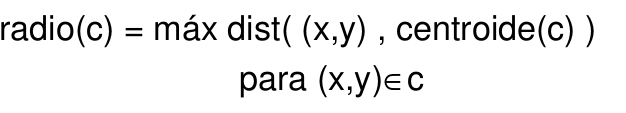

El radio de un clusters es la máxima distancia de los puntos del cluster a su centroide


In [66]:
def calcular_radio(cluster):
    centroide = calcular_centroide(cluster)

    dis_max = 0
    for x, y in cluster:
        distancia_actual = calcular_dis_euclidiana((x, y), centroide)

        if distancia_actual > dis_max:
            dis_max = distancia_actual

    radio = dis_max

    return radio

#### Calcular diametro

El diámetro de un cluster es la máxima distancia entre un par de puntos del cluster.

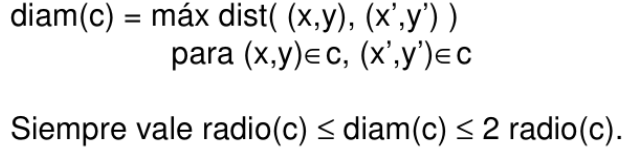


In [67]:
def calcular_diametro(cluster):
    dis_max = 0
    for i in range(len(cluster)):
        for j in range(i + 1, len(cluster)):
            distancia = calcular_dis_euclidiana(cluster[i], cluster[j])

            if distancia > dis_max:
                dis_max = distancia

    diametro = dis_max

    return diametro

print(calcular_diametro(cluster))

60.714578150556235


#### Calcular radio y diametro


In [68]:
diametro = calcular_diametro(cluster)
radio = calcular_radio(cluster)


print("Cluster", cluster)
print("Diametro", diametro)
print("Radio", radio)

Cluster [(0.2, 9.8), (15.3, -4.2), (-7.5, 3.1), (22.0, 18.4), (-12.7, -9.6), (5.5, 25.3), (-18.9, 14.2), (30.1, -20.5), (8.8, -15.7), (-25.0, 5.0)]
Diametro 60.714578150556235
Radio 36.533666665146


#### Graficando clusters

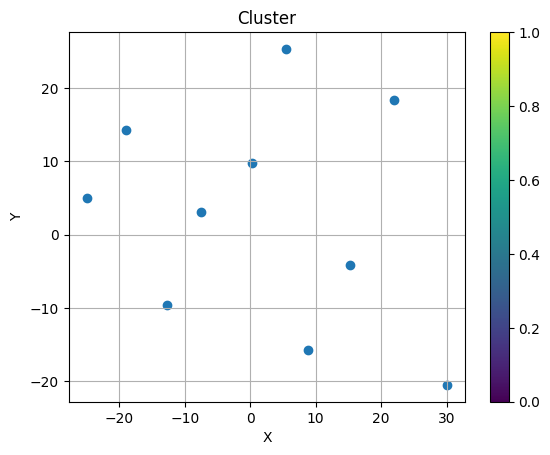

In [69]:
import matplotlib.pyplot as plt

x = [punto[0] for punto in cluster]
y = [punto[1] for punto in cluster]

plt.scatter(x, y)
plt.colorbar()
plt.title("Cluster")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

#### Usando Pandas

In [70]:
import pandas as pd

df = pd.read_csv("data.csv")

df = df.drop(columns=["id"])

df.head()

,latitude,longitude
0,-12.45,130.84
1,48.85,2.35
2,-33.87,151.21
3,35.68,139.69
4,55.75,37.62


#### K-means clustering

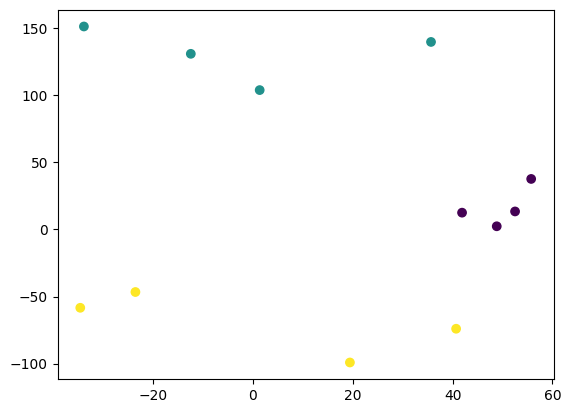

In [71]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)

kmeans.fit(df)

plt.scatter(df["latitude"], df["longitude"], c=kmeans.labels_)
plt.show()

### Ejercicio 3

Escribir un script que (sobre un ejemplo como el anterior) calcule KMeans con distintos valores de k (n_clusters) desde un mínimo hasta un máximo, y determine el mejor k, en el sentido de que sea mínima la varianza entre los diámetros de los clusters obtenidos.

Input:
$$Dataframe$$
Output:
$$kmeans$$

In [126]:
def calcular_dis_euclidiana(punto_a, punto_b):
    return math.sqrt(
        ((punto_a[0] - punto_b[0]) ** 2) + ((punto_a[1] - punto_b[1]) ** 2)
    )


def calc_diametro(cluster):

    max_distancia = 0
    for i in range(len(cluster)):
        for j in range(i + 1, len(cluster)):
            distancia = calcular_dis_euclidiana(cluster[i], cluster[j])

            if distancia > max_distancia:
                max_distancia = distancia

    return max_distancia


def calc_varianza(diametros):
    promedio = sum(diametros) / len(diametros)

    suma_varianza = 0
    for diam in diametros:
        suma_varianza += (diam - promedio) ** 2

    varianza = suma_varianza / len(diametros)

    return varianza


def calc_kmeans(df, k_min, k_max):

    if df is None or k_min is None or k_max is None:
        print("La función debe recibir un dataframe, un k mínimo y un k máximo")
        return

    valores_k = list(range(k_min, k_max))
    mejor_k = valores_k[0]
    varianza_min = float("inf")

    for valor_k in valores_k:
        kmeans = KMeans(n_clusters=valor_k)

        kmeans.fit(df)

        clusters_labels = kmeans.labels_

        copia_df = df.copy()

        copia_df["cluster_id"] = clusters_labels

        diametros = []
        for cluster_id in set(clusters_labels):
            puntos = copia_df[copia_df["cluster_id"] == cluster_id][
                ["latitude", "longitude"]
            ]

            diametro_cluster = calc_diametro(puntos.values.tolist())

            diametros.append(diametro_cluster)

        varianza_cluster = calc_varianza(diametros)

        if varianza_cluster < varianza_min:
            varianza_min = varianza_cluster
            mejor_k = valor_k

    return mejor_k


mejor_k = calc_kmeans(df, k_min=2, k_max=10)

print(f"MEJOR K: {mejor_k}")

MEJOR K: 9


#### K-means manual
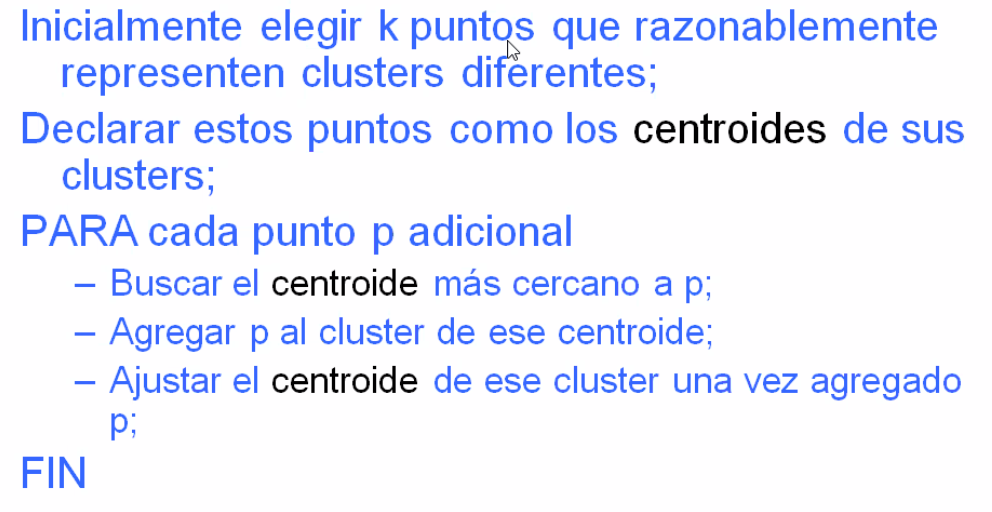

#### KNN manual

In [ ]:
import math

comidas = [
    {"nombre": "manzana", "crocancia": 8, "dulzor": 7, "tipo": "fruta"},
    {"nombre": "banana", "crocancia": 2, "dulzor": 9, "tipo": "fruta"},
    {"nombre": "zanahoria", "crocancia": 9, "dulzor": 4, "tipo": "vegetal"},
    {"nombre": "apio", "crocancia": 7, "dulzor": 3, "tipo": "vegetal"},
    {"nombre": "uva", "crocancia": 3, "dulzor": 8, "tipo": "fruta"},
    {"nombre": "pepino", "crocancia": 6, "dulzor": 5, "tipo": "vegetal"},
]

tomate = {"nombre": "tomate", "crocancia": 5, "dulzor": 6, "tipo": ""}

def dist_euclidiana(punto_a, punto_b):
    x_a = punto_a["crocancia"]
    y_a = punto_a["dulzor"]

    x_b = punto_b["crocancia"]
    y_b = punto_b["dulzor"]

    distancia = math.sqrt(((x_a - x_b) ** 2) + ((y_a - y_b) ** 2))
    return distancia

def clasificar_alimento(nuevo_alimento, lista_comidas, k):
    distancias = []
    for comida in lista_comidas:
        distancias.append(
            {"distancia": dist_euclidiana(comida, nuevo_alimento), "categoria": comida["tipo"]}
        )

    distancias.sort(key=lambda x: x["distancia"])

    vecinos_k = distancias[:k]

    conteo_categorias = {}

    for vecino in vecinos_k:
        cat = vecino["categoria"]
        if cat not in conteo_categorias:
            conteo_categorias[cat] = 1
        else:
            conteo_categorias[cat] += 1

    
    categoria_ganadora = max(conteo_categorias, key=conteo_categorias.get)
    
    return categoria_ganadora

resultado = clasificar_alimento(tomate, comidas, k=3)

print(f"El tomate fue clasificado como: {resultado}")


El tomate fue clasificado como: fruta


Con Counter

In [41]:
from collections import Counter
a = [1, 2, 3, 5, 6, 7, 8, 9, 10, 1, 4, 2]

Counter(a).most_common(1)

[(1, 2)]

#### KNN con sklearn

In [67]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn import datasets
from sklearn.model_selection import train_test_split

iris = datasets.load_iris()

X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



def dis_euclidiana(x, y):
    v1, v2 = np.array(x), np.array(y)

    return np.sqrt(np.sum((v1 - v2) ** 2))


class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X_test):
        distances = [dis_euclidiana(X_test, e) for e in self.X_train]
        k_indices = np.argsort(distances)[: self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        most_common_k = Counter(k_nearest_labels).most_common(1)[0][0]

        return most_common_k

    def predict_batch(self, X_test):
        return [self.predict(x) for x in X_test]


knn = KNN(k=3)
knn.fit(X, y)

predict_single = knn.predict(X_test[0])


predict_batch = knn.predict_batch(X_test)


print(predict_single)
print(predict_batch)

1
[np.int64(1), np.int64(0), np.int64(2), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(2), np.int64(0), np.int64(2), np.int64(0), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(2), np.int64(0), np.int64(0)]


#### Ejercicio 4 KNN
- ejercicio: aplicarlo a tablas conocidas
- ejercicio: modificarlo para que tome 5 vecinos, considere el 25% de los casos para test, y con la métrica de Manhattan
- ejercicio: usando lo hecho en la medida de lo posible, calcular la planta más alejada de la primera que aparece en la tabla

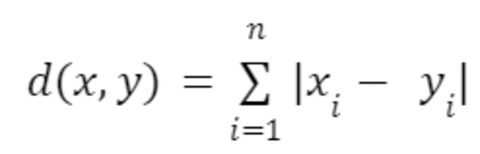

In [ ]:
def dis_manhattan(x, y):
    v1, v2 = np.array(x), np.array(y)

    return sum(abs(v1 - v2))

np.int64(13)